In [13]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

print(df.head())

print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [14]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [15]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [16]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

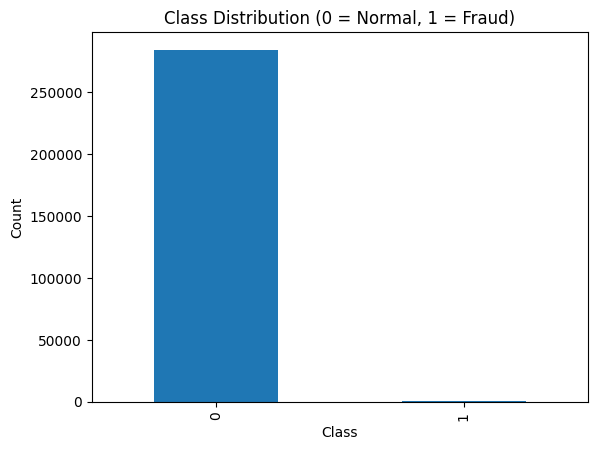

In [17]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [18]:
print(df.groupby('Class')['Amount'].describe())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Drop original columns
df = df.drop(['Amount', 'Time'], axis=1)

# Check result
print(df.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  scaled_amount  scaled_time  

In [20]:
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df = df.drop(['scaled_amount', 'scaled_time'], axis=1)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print(df.head())

   scaled_amount  scaled_time        V1        V2        V3        V4  \
0       0.244964    -1.996583 -1.359807 -0.072781  2.536347  1.378155   
1      -0.342475    -1.996583  1.191857  0.266151  0.166480  0.448154   
2       1.160686    -1.996562 -1.358354 -1.340163  1.773209  0.379780   
3       0.140534    -1.996562 -0.966272 -0.185226  1.792993 -0.863291   
4      -0.073403    -1.996541 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V20       V21       V22  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.251412 -0.018307  0.277838   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.069083 -0.225775 -0.638672   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.524980  0.247998  0.771679   
3 -0.010309  1.247203  0.237609  0.377436  ... -0.208038 -0.108300  0.005274   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.408542 -0.009431  0.798278   

        V23       V24       V25       V26       V27       V28  Class  
0 -0.1104

In [21]:
X = df.drop('Class', axis=1)
y = df['Class']

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Fraud in train:", y_train.sum())
print("Fraud in test:", y_test.sum())

Train shape: (227845, 30)
Test shape: (56962, 30)
Fraud in train: 394
Fraud in test: 98


In [23]:
!pip install imbalanced-learn -q

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [25]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42)

iso_forest.fit(X_train)

y_pred_iso = iso_forest.predict(X_test)

y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_iso))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_iso, digits=4))

Confusion Matrix:
[[56786    78]
 [   65    33]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9986    0.9987     56864
           1     0.2973    0.3367    0.3158        98

    accuracy                         0.9975     56962
   macro avg     0.6481    0.6677    0.6573     56962
weighted avg     0.9976    0.9975    0.9976     56962



In [27]:
X_train_normal = X_train[y_train == 0]

print(X_train_normal.shape)

(227451, 30)


In [28]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(20, activation='relu')(input_layer)
encoded = Dense(10, activation='relu')(encoded)
bottleneck = Dense(5, activation='relu')(encoded)
decoded = Dense(10, activation='relu')(bottleneck)
decoded = Dense(20, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │           630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,795 (7.01 KB)

 Trainable params: 1,795 (7.01 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.6910 - val_loss: 0.5064
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.4752 - val_loss: 0.4377
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4229 - val_loss: 0.4148
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3991 - val_loss: 0.3828
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3844 - val_loss: 0.3710
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3747 - val_loss: 0.3616
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3659 - val_loss: 0.3537
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3587 - val_loss: 0.3500
Epoch 9/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3520 - val_loss: 0.3406
Epoch 10/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3460 - val_loss: 0.3349
Epoch 11/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3419 - val_loss: 0.3310
Epoch 12/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/ste

In [30]:
import numpy as np

reconstructions = autoencoder.predict(X_test)

mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

error_df = pd.DataFrame({'reconstruction_error': mse, 'true_class': y_test})

print(error_df.describe())

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
       reconstruction_error    true_class
count          56962.000000  56962.000000
mean               0.352170      0.001720
std                1.333747      0.041443
min                0.027359      0.000000
25%                0.148282      0.000000
50%                0.226000      0.000000
75%                0.357345      0.000000
max               71.550783      1.000000


In [31]:
threshold = np.percentile(error_df['reconstruction_error'], 99)  # top 1% = flagged
print("Threshold:", threshold)

error_df['predicted_class'] = (error_df['reconstruction_error'] > threshold).astype(int)

print(confusion_matrix(error_df['true_class'], error_df['predicted_class']))
print(classification_report(error_df['true_class'], error_df['predicted_class'], digits=4))

Threshold: 1.647009523778644
[[56375   489]
 [   17    81]]
              precision    recall  f1-score   support

           0     0.9997    0.9914    0.9955     56864
           1     0.1421    0.8265    0.2425        98

    accuracy                         0.9911     56962
   macro avg     0.5709    0.9090    0.6190     56962
weighted avg     0.9982    0.9911    0.9942     56962



In [32]:
from sklearn.metrics import precision_recall_curve, auc

# For autoencoder
precision, recall, thresholds = precision_recall_curve(error_df['true_class'], error_df['reconstruction_error'])
pr_auc = auc(recall, precision)
print("PR-AUC (Autoencoder):", pr_auc)

PR-AUC (Autoencoder): 0.515490726367915


In [33]:

for pct in [95, 97, 99, 99.5, 99.9]:
    t = np.percentile(error_df['reconstruction_error'], pct)
    preds = (error_df['reconstruction_error'] > t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(error_df['true_class'], preds)
    r = recall_score(error_df['true_class'], preds)
    f1 = f1_score(error_df['true_class'], preds)
    print(f"Percentile {pct}: threshold={t:.4f}, precision={p:.4f}, recall={r:.4f}, f1={f1:.4f}")

Percentile 95: threshold=0.7660, precision=0.0291, recall=0.8469, f1=0.0563
Percentile 97: threshold=0.9602, precision=0.0486, recall=0.8469, f1=0.0919
Percentile 99: threshold=1.6470, precision=0.1421, recall=0.8265, f1=0.2425
Percentile 99.5: threshold=2.4953, precision=0.2807, recall=0.8163, f1=0.4178
Percentile 99.9: threshold=13.9043, precision=0.6140, recall=0.3571, f1=0.4516


In [34]:
final_threshold = np.percentile(error_df['reconstruction_error'], 99.5)
error_df['alert'] = (error_df['reconstruction_error'] > final_threshold).astype(int)

print("Total alerts raised:", error_df['alert'].sum())

Total alerts raised: 285


In [35]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 99.3 MB/s eta 0:00:00


In [36]:
error_df.to_csv('fraud_alerts.csv', index=False)

In [46]:
comparison.to_csv('model_comparison.csv', index=False)

In [45]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.set_page_config(page_title="Fraud Detection Dashboard", layout="wide")

st.title("🚨 Fraud Detection Alert Dashboard")

# Load autoencoder alert data
df = pd.read_csv('fraud_alerts.csv')

# Top metrics
col1, col2, col3 = st.columns(3)
col1.metric("Total Transactions", len(df))
col2.metric("Total Alerts Raised", int(df['alert'].sum()))
col3.metric("Actual Fraud Cases", int(df['true_class'].sum()))

st.subheader("🔍 Flagged Transactions (Alerts)")
alerts = df[df['alert'] == 1].sort_values('reconstruction_error', ascending=False)
st.dataframe(alerts)

st.subheader("📊 Reconstruction Error Distribution")
st.bar_chart(df['reconstruction_error'])

st.subheader("⚙️ Filter Alerts")
min_error = st.slider("Minimum reconstruction error", 0.0, float(df['reconstruction_error'].max()), 1.0)
filtered = df[df['reconstruction_error'] > min_error]
st.write(f"Transactions above threshold {min_error}: {len(filtered)}")
st.dataframe(filtered)

# Model comparison section
st.subheader("🏆 Model Comparison")
comparison_df = pd.read_csv('model_comparison.csv')
st.dataframe(comparison_df)
st.bar_chart(comparison_df.set_index('Model')[['Precision', 'Recall', 'F1-Score']])

st.caption("Random Forest + SMOTE performed best overall, since it's a supervised model trained on labeled, balanced data. Isolation Forest and Autoencoder are unsupervised — they detect anomalies without ever seeing fraud labels, which is more realistic for catching new/unknown fraud patterns in production.")

Overwriting app.py


In [47]:
!pkill -f streamlit
!streamlit run app.py &>/content/logs.txt &

In [48]:
from pyngrok import ngrok
ngrok.kill()
public_url = ngrok.connect(8501)
print("Your dashboard link:", public_url)

Your dashboard link: NgrokTunnel: "https://dramatic-roundish-pointed.ngrok-free.dev" -> "http://localhost:8501"


In [38]:
!pip install pyngrok -q

In [49]:
from pyngrok import ngrok

ngrok.set_auth_token("3IMRnobvBYxiBUhVM8lWcxP1x7u_2X5EDv1ntkEs4XW7rNSU3")

In [42]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42)
iso_forest.fit(X_train)

y_pred_iso = iso_forest.predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

print("Confusion Matrix (Isolation Forest):")
print(confusion_matrix(y_test, y_pred_iso))

print("\nClassification Report (Isolation Forest):")
print(classification_report(y_test, y_pred_iso, digits=4))

Confusion Matrix (Isolation Forest):
[[56786    78]
 [   65    33]]

Classification Report (Isolation Forest):
              precision    recall  f1-score   support

           0     0.9989    0.9986    0.9987     56864
           1     0.2973    0.3367    0.3158        98

    accuracy                         0.9975     56962
   macro avg     0.6481    0.6677    0.6573     56962
weighted avg     0.9976    0.9975    0.9976     56962



In [43]:
from sklearn.ensemble import RandomForestClassifier

# Train on SMOTE-balanced data
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_smote.predict(X_test)

print("Confusion Matrix (Random Forest + SMOTE):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (Random Forest + SMOTE):")
print(classification_report(y_test, y_pred_rf, digits=4))

Confusion Matrix (Random Forest + SMOTE):
[[56851    13]
 [   18    80]]

Classification Report (Random Forest + SMOTE):
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997     56864
           1     0.8602    0.8163    0.8377        98

    accuracy                         0.9995     56962
   macro avg     0.9299    0.9080    0.9187     56962
weighted avg     0.9994    0.9995    0.9994     56962



In [44]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'Autoencoder', 'Random Forest + SMOTE'],
    'Precision': [
        classification_report(y_test, y_pred_iso, output_dict=True)['1']['precision'],
        0.2772,  # from your earlier 99.5 percentile result
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['precision']
    ],
    'Recall': [
        classification_report(y_test, y_pred_iso, output_dict=True)['1']['recall'],
        0.8061,
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']
    ],
    'F1-Score': [
        classification_report(y_test, y_pred_iso, output_dict=True)['1']['f1-score'],
        0.4125,
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score']
    ]
})

print(comparison)

                   Model  Precision    Recall  F1-Score
0       Isolation Forest   0.297297  0.336735  0.315789
1            Autoencoder   0.277200  0.806100  0.412500
2  Random Forest + SMOTE   0.860215  0.816327  0.837696


In [51]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn

Writing requirements.txt


In [55]:
from google.colab import files
files.download('app.py')
files.download('requirements.txt')
files.download('fraud_alerts.csv')
files.download('model_comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
!ls

app.py		fraud_alerts.csv  model_comparison.csv	sample_data
creditcard.csv	logs.txt	  requirements.txt
